# Customer Churn Analysis Using Python & SQL

## Business Challenge

In the highly competitive OTT subscription industry, retaining existing customers is more cost-effective than acquiring new ones. Customer churn directly affects revenue, customer retention, and long-term business growth. The company needs to identify customers who are at risk of leaving, understand the key factors influencing churn, and develop data-driven strategies to improve customer retention and customer satisfaction.

## Problem Statement

The objective of this project is to analyze customer churn using subscription, customer, and support datasets by integrating SQL and Python. The project focuses on cleaning and merging data, calculating key business KPIs such as churn rate, retention rate, average complaints, customer tenure, and correlation analysis, and creating visualizations to identify churn trends across subscription plans, states, and time periods. Based on these insights, actionable recommendations are provided to help reduce customer churn and improve retention

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#1.import database/data

In [3]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

tables = pd.read_sql(sql_query, conn)

#create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe : df_{table_name}")
    
conn.close()

Created dataframe : df_db_customer
Created dataframe : df_db_subscription
Created dataframe : df_db_support


In [4]:
#Print table name and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name:{table_name}")
    #Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())
    
#Close connection
conn.close()


Table Name:db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name:db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name:db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
#2. data cleaning

In [6]:
#df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [7]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [8]:
#a. rename col - name
#b. drop columns - interest and pincode
#c. change data type  - dob
#d. data standardization - gender
#e. fix missing values - country

In [9]:
#a. rename col - name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)

In [10]:
#b. drop columns - interest and pincode

#df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
df_db_customer.drop(columns=['interests', 'pincode'],inplace = True)

In [11]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [12]:
#c. change data type  - dob

df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [13]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [14]:
#d. data standardization - gender

#df_db_customer['gender'].unique()
#df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})    run this code first 
df_db_customer['gender']=df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'}) #for saving the above output we write like this after writing run it

In [15]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [16]:
#e. fix missing values - country

#df_db_customer['country'].isna()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [17]:
#country and state - unique value pair
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping)) #tosave this code first run above codethen run last code

In [18]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [19]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [20]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [21]:
date_col = ['subscription_start_date','renewal_date', 'cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [22]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [23]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [24]:
df_db_support.drop(columns=['col_1', 'comment'],inplace = True)

In [25]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [26]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [27]:
#3. Feature Engineering and Data Analysis

In [28]:
#create a new col using existing col - churn flag
#np.where(df_db_subscription['cancellation_date'].notna(), 1,0)
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(), 1,0)

In [29]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [30]:
df_db_subscription.merge(df_db_customer, on = 'customerid', how = 'left')

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,41,0,arjun,Nepal,Kathmandu,Male,1993-10-29


In [31]:
#first fix support table duplicate then merge
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how = 'left')
            .merge(df_db_support, on = 'customerid', how = 'left'))

In [32]:
df.shape

(23, 20)

In [33]:
df_db_subscription.shape

(21, 12)

In [34]:
df_db_subscription['customerid'].nunique()

21

In [35]:
df_db_customer['customerid'].nunique()

21

In [36]:
df_db_support['customerid'].nunique()

7

In [37]:
df_db_support['customerid'].size   #here 2 rows are repeated

9

In [38]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [39]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [40]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [41]:
df_db_support['customerid'].size 

7

In [42]:
#merge dataframe after removing duplicates
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how = 'left')
            .merge(df_db_support, on = 'customerid', how = 'left'))

In [43]:
df.shape

(21, 21)

In [44]:
df.to_csv('exported_churn_data.csv',index = False)

In [45]:
#Data Analysis

In [46]:
#1.Churn Rate

In [47]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [48]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate =", round(churn_rate,2),"%")

Churn Rate = 28.57 %


In [49]:
#2. Retention Rate   #customer continue to stay with company
retention_rate = 100 - churn_rate
print("Retention Rate = ",round(retention_rate,2),"%")

Retention Rate =  71.43 %


In [50]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [51]:
#3. Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [52]:
#4a. Churn by State + sum(revenue) & count of users
churn_by_state = df.groupby('state').agg(total_revenue=('monthly_charges','sum'),total_users=('customerid','count')).reset_index()
print(churn_by_state)

           state  total_revenue  total_users
0          Delhi          52.96            4
1      Karnataka          20.98            2
2      Kathmandu          20.98            2
3    Maharashtra          50.97            3
4      Meghalaya          42.97            3
5       Nagaland          22.99            1
6      Rajasthan          36.98            2
7      Telangana          30.98            2
8  Uttar Pradesh         115.98            2


In [53]:
#4b. churn by subscription type + sum(revenue) & count of users
churn_by_subscription_type = df.groupby('subscription_type').agg(total_revenue=('monthly_charges','sum'),total_users=('customerid','count')).reset_index()
print(churn_by_subscription_type)

  subscription_type  total_revenue  total_users
0           Organic         145.91            9
1              Paid         174.94            6
2          Refferal          74.94            6


In [54]:
#5 ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ',round(arpu,2))

ARPU =  18.85


In [55]:
#6. Avg Customer Tenure
#count of days users has used our services : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),

  (df['cancellation_date'] - df['subscription_start_date']).dt.days,

   (today - df['subscription_start_date']).dt.days
)
avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ",round(avg_tenure),0)

Avg Tenure (Days) =  1496 0


In [56]:
#7. Revenue at risk - revenue last from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K')=",revenue_at_risk)

Revenue at Risk (Rs 'K')= 73.94


In [57]:
#8.Esclation Rate
escalation_rate =(df['escalations']=='Y').mean()*100
print("Escalation Rate =",round(escalation_rate,2),"%")

Escalation Rate = 19.05 %


In [58]:
#9. Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaints Per User = ",round(avg_complaints, 2))

Avg Complaints Per User =  0.43


In [108]:
#10. Correlation Esclation vs Churn
# Fill missing values
df['escalations'] = df['escalations'].fillna(0).astype(int)

# Correlation
correlation = df['escalations'].corr(df['churn_flag'])

print("Correlation between Escalations vs Churn =", round(correlation, 2))

Correlation between Escalations vs Churn = 0.77


In [111]:
#11. Churn risk - create a column using existing col
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >=50) & (df['churn_score'] < 70),
    (df['churn_score'] >=70)
]
choices = ['low','med','high']
df['churn_risk'] = np.select(conditions, choices, default='unknown')

In [110]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk,cancellation_month
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1949.0,low,NaT
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high,2024-09
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1334.0,low,NaT
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2624.0,low,NaT
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high,2024-02


In [ ]:
#4. Visualization using Matplotlib

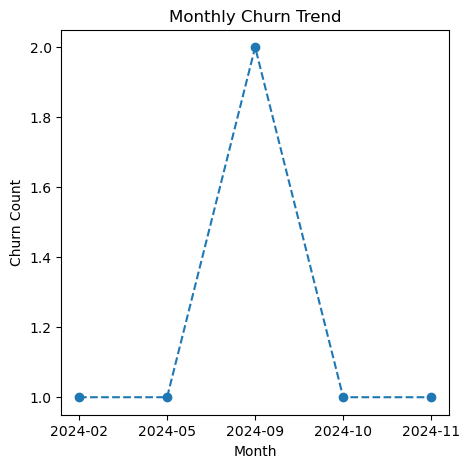

In [76]:
 #4.1 Monthly Churn Trend (Time Series KPI)
df['cancellation_month'] = df['cancellation_date'].dt.to_period('M')
monthly_churn = df.groupby('cancellation_month')['churn_flag'].sum()
plt.figure(figsize=(5,5))
plt.plot(monthly_churn.index.astype(str), monthly_churn.values, marker='o', linestyle='dashed')
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churn Count')
plt.show()

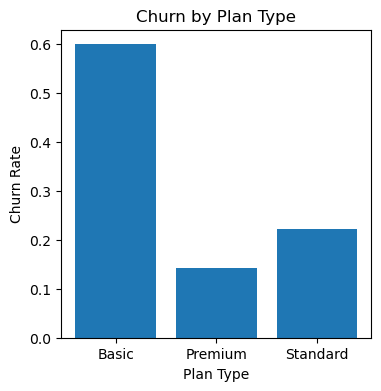

In [78]:
#4.2 Churn by Plan type
churn_plan = df.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(4,4))
plt.bar(churn_plan.index, churn_plan.values)
plt.title("Churn by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate")
plt.show()

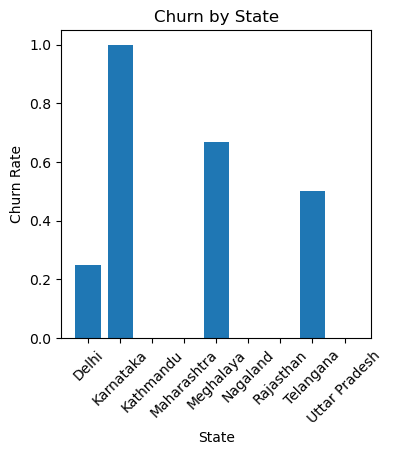

In [79]:
#4.3 Churn by States
state_churn = df.groupby('state')['churn_flag'].mean()
plt.figure(figsize=(4,4))
plt.bar(state_churn.index, state_churn.values)
plt.title("Churn by State")
plt.xlabel("State")
plt.ylabel("Churn Rate")

plt.xticks(rotation=45)
plt.show()

In [ ]:
#Visualisation using Seaborn

In [84]:
df['escalations'] = df['escalations'].fillna(0)
df['escalations'] = df['escalations'].astype(int)
df['escalations'].value_counts(dropna=False)

escalations
0    17
1     4
Name: count, dtype: int64

In [85]:
df[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [87]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


In [86]:
#incorrect method of encoding -as numbers are not assigned based on priority
df_encoded = df[['plan_type','contract_type','churn_score',
                 'churn_flag','churn_risk','escalations']]

categirial_cols = ['plan_type','contract_type','churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

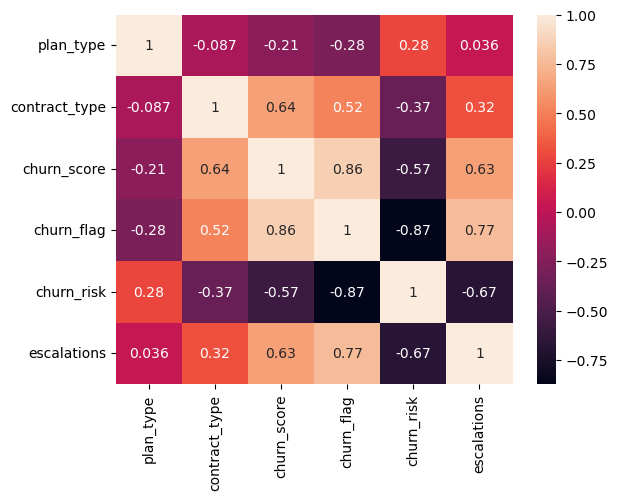

In [89]:
#Heatmap(correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

In [93]:
import warnings
warnings.filterwarnings("ignore")

In [94]:
# correct method of encoding -based on priority
df_encoded = df[['plan_type','contract_type','churn_score',
                 'churn_flag','churn_risk','escalations']]

order_mappings = {
    'plan_type' : ['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','med','high']
    }
for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories=order, ordered=True).codes

In [95]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

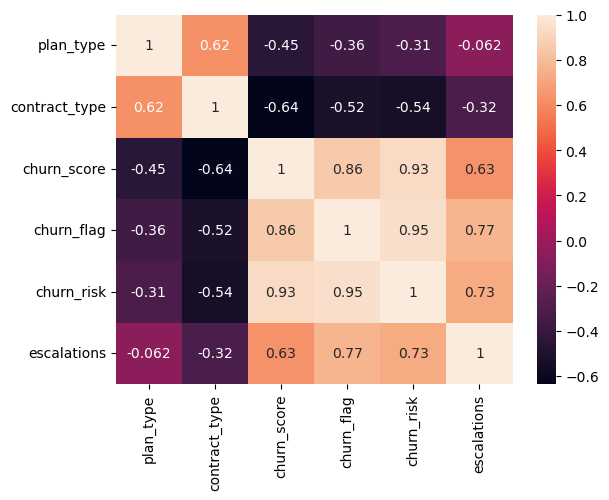

In [96]:
#Heatmap(correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

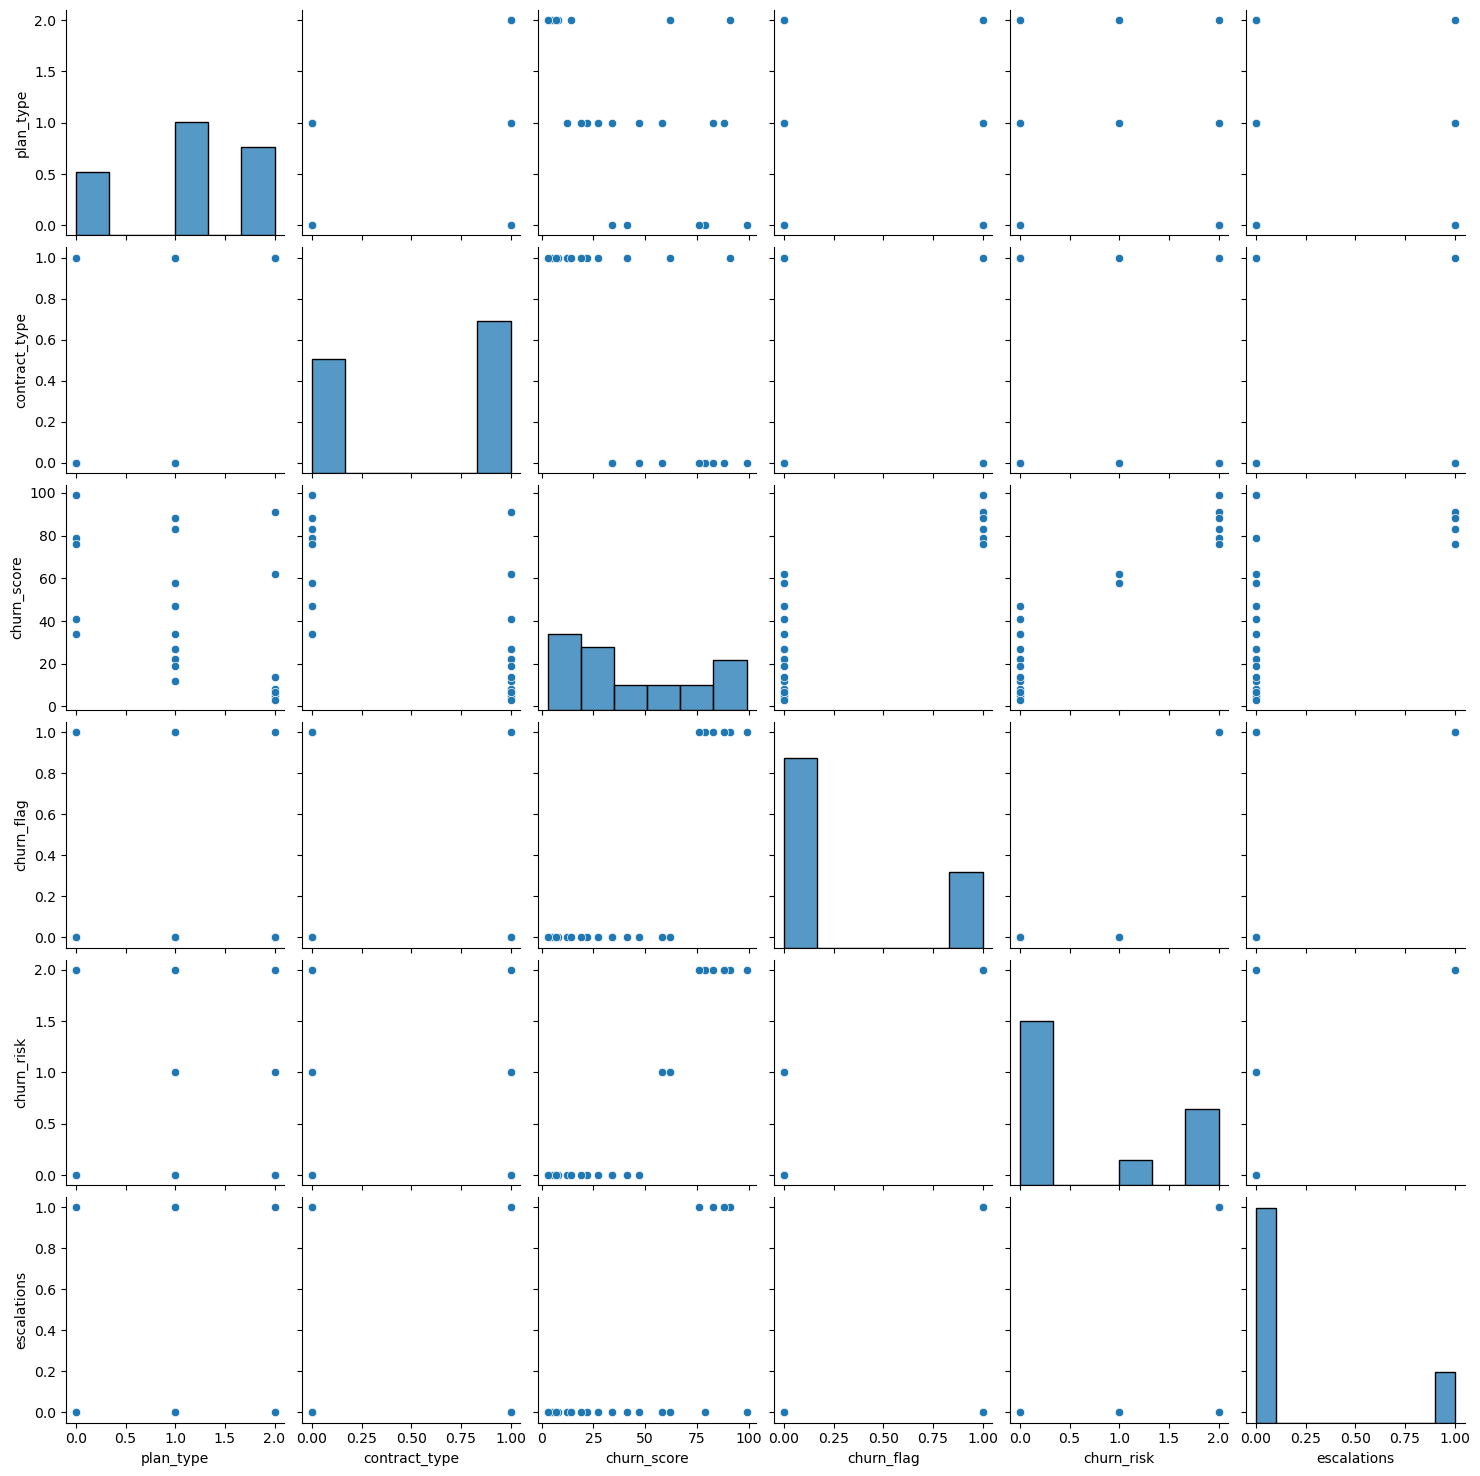

In [97]:
#pairplot - relationship in a dataset
sns.pairplot(df_encoded)

# Business Insights & Recommendations

# Business Insights
1. Overall Churn Rate: 28.57%, while the Retention Rate is 71.43%, indicating that most customers continue using the service.
2. Customers with higher churn scores are significantly more likely to cancel their subscriptions.
3. Escalations (customer complaints) show a strong positive correlation (~0.77) with churn, suggesting that unresolved support issues increase customer attrition.
4. The highest number of cancellations occurred in September 2024, indicating a possible seasonal trend or business event that should be investigated.
5. Karnataka recorded the highest churn, making it the most affected state.
6. Customers on the Basic subscription plan contribute the largest share of churn, whereas Premium customers show better retention.
7. Annual subscription plans have lower churn than Monthly plans, indicating that long-term contracts improve customer retention.


# Recommendations
1. Improve customer support response time to reduce complaint escalations.
2. Investigate the reasons behind the high churn in Karnataka, including pricing, service quality, or competitor activity.
3. Offer discounts or loyalty benefits to customers on the Basic plan to improve retention.
4. Encourage Monthly subscribers to upgrade to Annual plans through special offers.
5.Identify customers with high churn scores and contact them proactively with personalized offers before cancellation.
6. Continuously monitor monthly churn trends and customer feedback to detect future risks early.

In [ ]:
#Pivot Table

In [99]:
pd.pivot_table(
    df,
    index='plan_type',    #left col
    values='churn_flag',
    aggfunc= 'mean'
).reset_index()    

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [101]:
pd.pivot_table(
    df,
    index='plan_type',    #left col
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc= {
        'monthly_charges':'sum',
        'customerid':'nunique',   #nunique method is use to count customerid
        'churn_flag':'mean'
    }  
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [ ]:
#Working with sql in Python(pandas)

In [102]:
#create db in sql
conn = sqlite3.connect('test_database.sqlite')

#table details
conn.execute("CREATE TABLE users(first_name TEXT, country TEXT, budget INTEGER)")

#commit and save
conn.commit()

In [103]:
#insert data
cursor = conn.cursor()

#write sql query to insert records in sql table
cursor.execute(
    """
        INSERT INTO users VALUES 
            ('Madhav','India',5000),
            ('Sakshi','Germany',2500),
            ('Vishakha','India',3500)
    """
)

#commit and save
conn.commit()

print("Data Inserted successfully!")

Data Inserted successfully!


In [104]:
#check inserted data in table
conn = sqlite3.connect('test_database.sqlite')
query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Madhav,India,5000
1,Sakshi,Germany,2500
2,Vishakha,India,3500


In [105]:
#aggregation
query = """
       SELECT country, sum(budget) as total_budget
       FROM users
       GROUP BY country
""" 
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,2500
1,India,8500


In [106]:
#always close the conn with db once the task is over
conn.close()

# Summary
Engineered an end-to-end customer churn analytics pipeline by integrating subscription, customer, and support datasets using SQL and Python. Calculated key business KPIs including Churn Rate (28.57%), Retention Rate (71.43%), average complaints, customer tenure, and correlation analysis. Identified that the Basic subscription plan experienced the highest churn, with the largest number of cancellations occurring in September 2024, while Karnataka recorded the highest churn among all states. Correlation analysis showed a strong positive relationship (0.77) between escalated complaints and customer churn, indicating that unresolved customer issues significantly increase churn risk. The project concluded with actionable business recommendations focused on improving customer retention, reducing churn, and enhancing customer satisfaction through proactive support and targeted retention strategies.

In [112]:
import sqlite3

conn = sqlite3.connect("customer_churn.db")
print("Database Connected Successfully!")

Database Connected Successfully!
